In [1]:
# 07 - Principal Component Analysis on Breast Cancer Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
data = load_breast_cancer()
print("Keys:", list(data.keys()))
print("Target names:", data['target_names'])
print("Feature names (first 5):", data['feature_names'][:5])
print("Shape:", data['data'].shape)

Keys: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
Target names: ['malignant' 'benign']
Feature names (first 5): ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Shape: (569, 30)


In [4]:
df1 = pd.DataFrame(data['data'], columns=data['feature_names'])
print("DataFrame shape:", df1.shape)
print(df1.head())

DataFrame shape: (569, 30)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  wors

In [5]:
sc = StandardScaler()
sc.fit(df1)
scaled_data = sc.transform(df1)
print("Scaled shape:", scaled_data.shape)
print("Mean (should be ~0):", scaled_data.mean(axis=0).round(3)[:5])
print("Std  (should be 1):", scaled_data.std(axis=0).round(3)[:5])

Scaled shape: (569, 30)
Mean (should be ~0): [-0. -0. -0. -0.  0.]
Std  (should be 1): [1. 1. 1. 1. 1.]


In [6]:
# Apply PCA with 3 components

In [7]:
principal = PCA(n_components=3)
principal.fit(scaled_data)
x = principal.transform(scaled_data)
print("Projected shape:", x.shape)

Projected shape: (569, 3)


In [8]:
print("Explained variance ratio:")
print(principal.explained_variance_ratio_)
print()
print("Total variance captured by 3 components:",
      round(principal.explained_variance_ratio_.sum() * 100, 2), "%")

Explained variance ratio:
[0.44272026 0.18971182 0.09393163]

Total variance captured by 3 components: 72.64 %


In [9]:
# 2D Scatter Plot - PC1 vs PC2

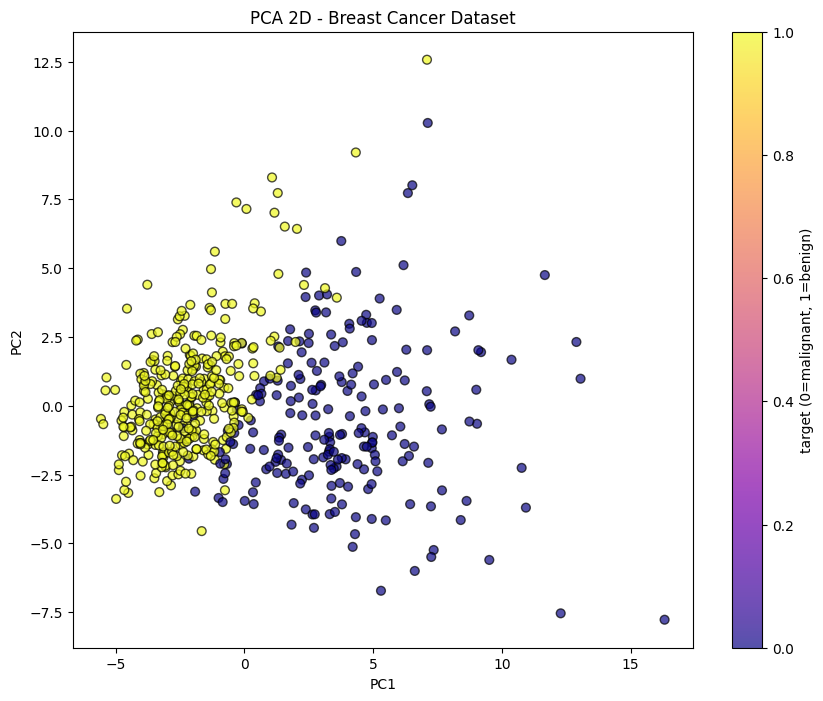

In [10]:
plt.figure(figsize=(10, 8))
plt.scatter(x[:, 0], x[:, 1], c=data['target'], cmap='plasma',
            s=40, edgecolors='k', alpha=0.7)
plt.title('PCA 2D - Breast Cancer Dataset')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='target (0=malignant, 1=benign)')
plt.show()

In [11]:
# 3D Scatter Plot - PC1, PC2, PC3

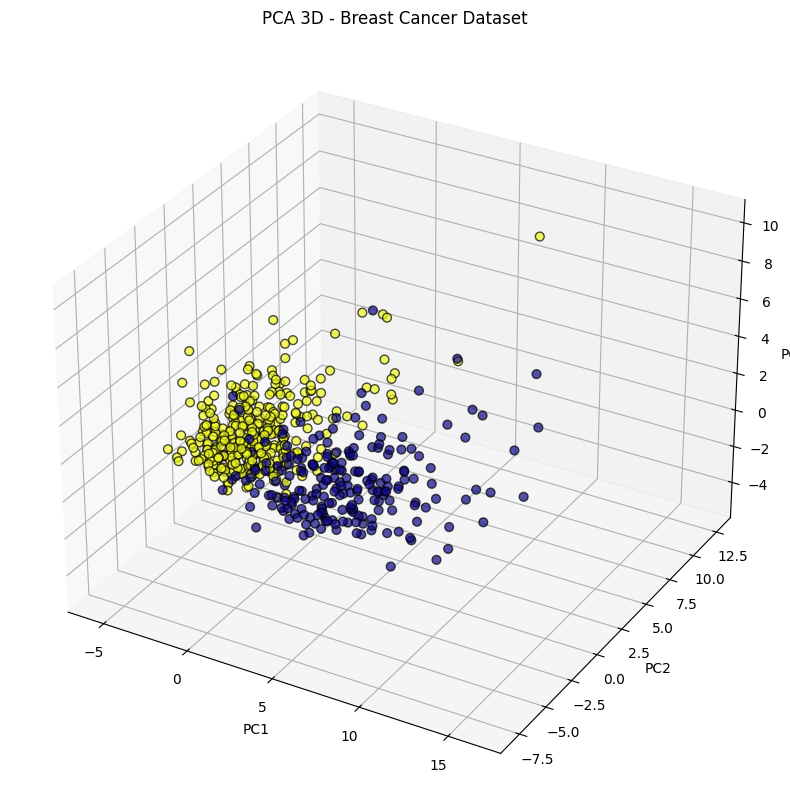

In [12]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:, 0], x[:, 1], x[:, 2], c=data['target'], cmap='plasma',
          s=40, edgecolors='k', alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA 3D - Breast Cancer Dataset')
plt.show()

In [13]:
# Variance Explained - Cumulative Plot

In [14]:
pca_full = PCA(n_components=30)
pca_full.fit(scaled_data)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

print("Top-10 explained variance ratios:")
for i, (e, c) in enumerate(zip(evr[:10], cum[:10]), 1):
    print("  PC%2d: %.4f  cumulative = %.4f" % (i, e, c))

n95 = int(np.argmax(cum >= 0.95) + 1)
print()
print("Components needed for 95% variance:", n95)

Top-10 explained variance ratios:
  PC 1: 0.4427  cumulative = 0.4427
  PC 2: 0.1897  cumulative = 0.6324
  PC 3: 0.0939  cumulative = 0.7264
  PC 4: 0.0660  cumulative = 0.7924
  PC 5: 0.0550  cumulative = 0.8473
  PC 6: 0.0402  cumulative = 0.8876
  PC 7: 0.0225  cumulative = 0.9101
  PC 8: 0.0159  cumulative = 0.9260
  PC 9: 0.0139  cumulative = 0.9399
  PC10: 0.0117  cumulative = 0.9516

Components needed for 95% variance: 10


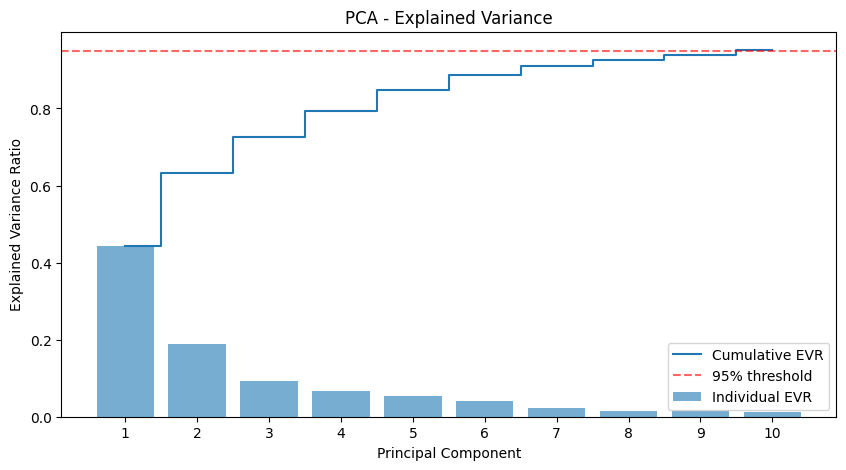

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), evr[:10], alpha=0.6, label='Individual EVR')
plt.step(range(1, 11), cum[:10], where='mid', label='Cumulative EVR')
plt.axhline(0.95, color='red', linestyle='--', alpha=0.6, label='95% threshold')
plt.xticks(range(1, 11))
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA - Explained Variance')
plt.legend()
plt.show()